             Total      Rating
count  1000.000000  1000.00000
mean    322.966749     6.97270
std     245.885335     1.71858
min      10.678500     4.00000
25%     124.422375     5.50000
50%     253.848000     7.00000
75%     471.350250     8.50000
max    1042.650000    10.00000


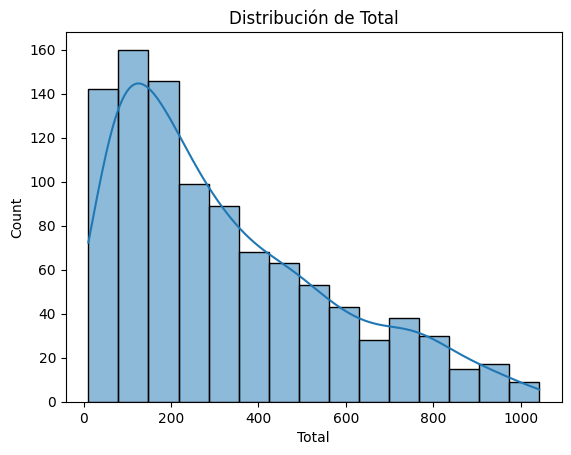

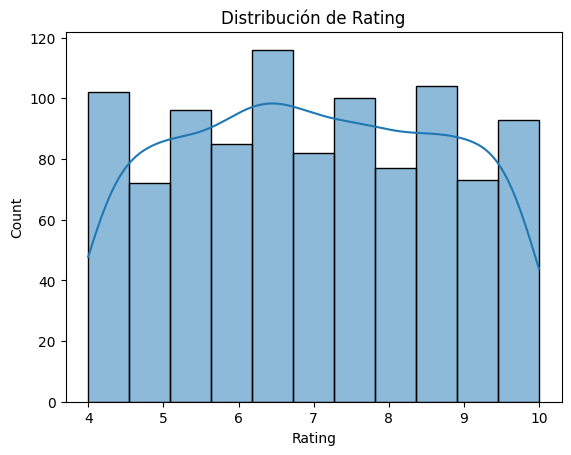


Customer type:
 Customer type
Member    0.501
Normal    0.499
Name: proportion, dtype: float64


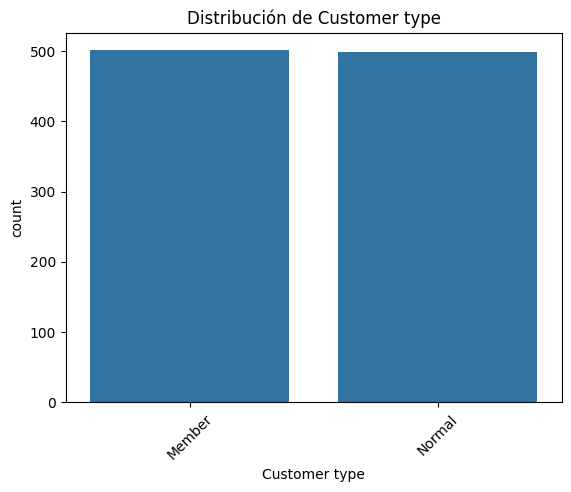


Gender:
 Gender
Female    0.501
Male      0.499
Name: proportion, dtype: float64


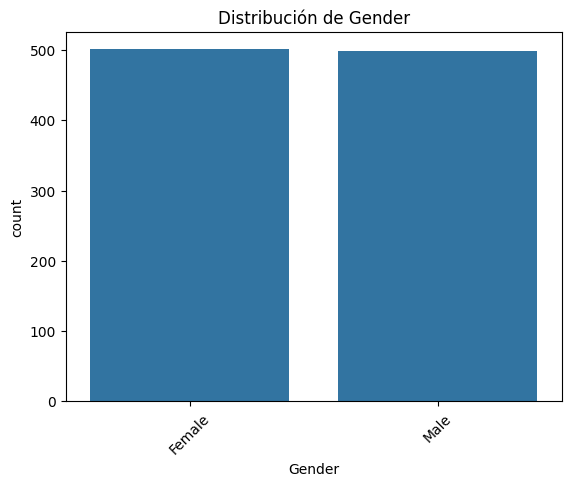


Product line:
 Product line
Fashion accessories       0.178
Food and beverages        0.174
Electronic accessories    0.170
Sports and travel         0.166
Home and lifestyle        0.160
Health and beauty         0.152
Name: proportion, dtype: float64


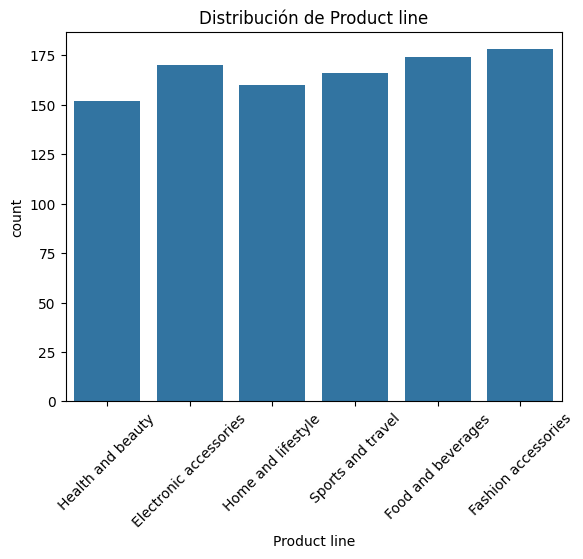


Payment:
 Payment
Ewallet        0.345
Cash           0.344
Credit card    0.311
Name: proportion, dtype: float64


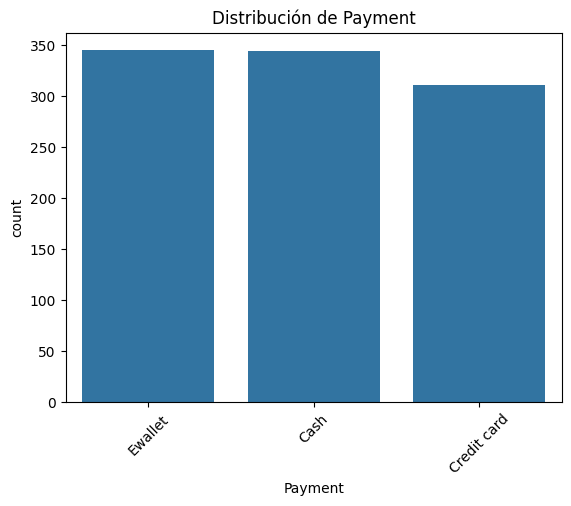

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np


# Cargar datos
df = pd.read_csv("data//clientes.csv")

# Filtrar columnas relevantes
cols = ["Total", "Rating", "Customer type", "Gender", "Product line", "Payment"]
df = df[cols].dropna()

# EDA numéricas
print(df[["Total", "Rating"]].describe())

# Distribuciones
sns.histplot(df["Total"], kde=True)
plt.title("Distribución de Total")
plt.show()

sns.histplot(df["Rating"], kde=True)
plt.title("Distribución de Rating")
plt.show()

# EDA categóricas
for col in ["Customer type", "Gender", "Product line", "Payment"]:
    print(f"\n{col}:\n", df[col].value_counts(normalize=True).round(3))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.show()




In [19]:





# Función para embedding individual
def embed_column(df, col, n_components=2):
    vec = CountVectorizer()
    mat = vec.fit_transform(df[col].astype(str))
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    return svd.fit_transform(mat)

# Embeddings
embed_customer = embed_column(df, "Customer type")
embed_gender = embed_column(df, "Gender")
embed_product = embed_column(df, "Product line")
embed_payment = embed_column(df, "Payment")

# Escalar numéricas
num_scaled = StandardScaler().fit_transform(df[["Total", "Rating"]])

# Matriz final
X = np.hstack([
    num_scaled,
    embed_customer,
    embed_gender,
    embed_product,
    embed_payment
])

In [20]:
from sklearn.cluster import KMeans

k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X)
df_clean = df.copy()
df["cluster_k4"] = labels
df_k4 = df

In [21]:

k2 = 5
km2 = KMeans(n_clusters=k2, random_state=42, n_init=10)
labels2 = km2.fit_predict(X)
df2 = df_clean.copy()
df2["cluster_k5"] = labels2
df_k5 = df2


e:\prj\env_supermarket\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



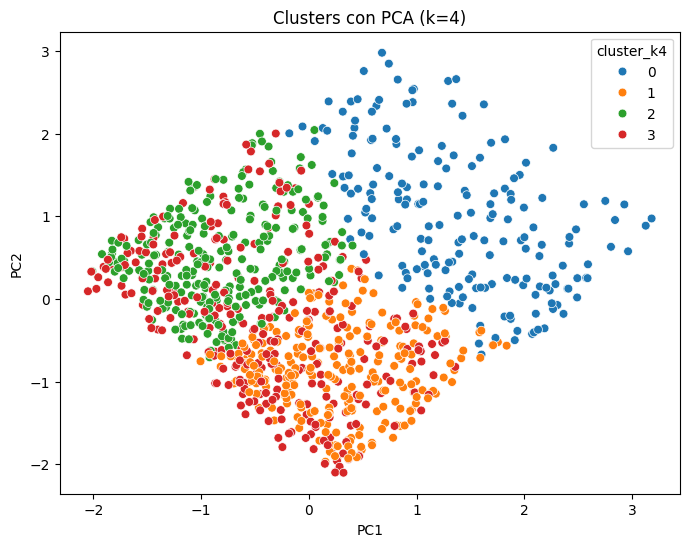

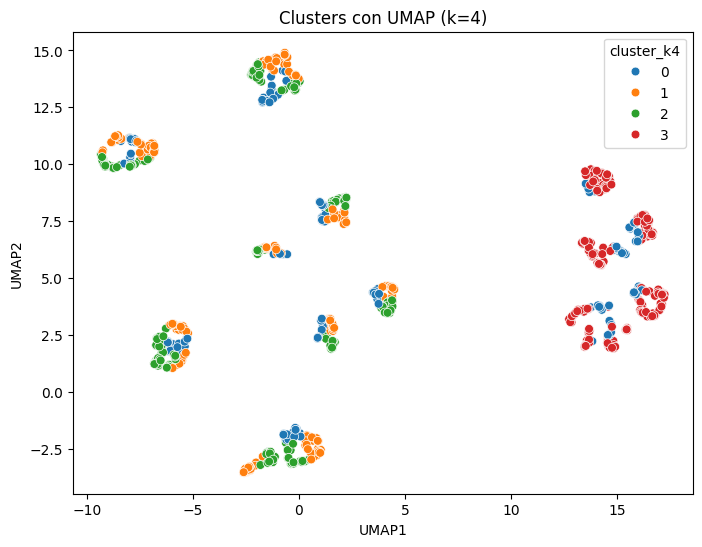

In [22]:
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
df["PC1"] = X_pca[:,0]
df["PC2"] = X_pca[:,1]

# UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)
df["UMAP1"] = X_umap[:,0]
df["UMAP2"] = X_umap[:,1]

# Gráficos
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="cluster_k4", palette="tab10", s=40)
plt.title("Clusters con PCA (k=4)")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="UMAP1", y="UMAP2", hue="cluster_k4", palette="tab10", s=40)
plt.title("Clusters con UMAP (k=4)")
plt.show()

In [23]:
# Numéricas
def cluster_numeric_summary(df, cluster_col, num_cols):
    return df.groupby(cluster_col)[num_cols].agg(["count", "mean", "std"]).round(2)

num_summary = cluster_numeric_summary(df, "cluster_k4", ["Total", "Rating"])
print(num_summary)

# Categóricas
def cluster_category_summary(df, cluster_col, cat_cols, top_n=3):
    result = {}
    for cluster in sorted(df[cluster_col].unique()):
        sub = df[df[cluster_col] == cluster]
        summary = {}
        for col in cat_cols:
            vc = sub[col].value_counts(normalize=True).head(top_n)
            summary[col] = "; ".join([f"{idx} ({round(val*100,1)}%)" for idx, val in vc.items()])
        result[cluster] = summary
    return pd.DataFrame(result).T

cat_summary = cluster_category_summary(df, "cluster_k4", ["Customer type", "Gender", "Product line", "Payment"])
print(cat_summary)

           Total                 Rating            
           count    mean     std  count  mean   std
cluster_k4                                         
0            188  734.96  135.01    188  6.55  1.66
1            259  217.60  137.19    259  5.55  0.90
2            266  243.75  154.36    266  8.52  0.84
3            287  221.59  149.77    287  7.09  1.71
                    Customer type                        Gender  \
0  Member (53.2%); Normal (46.8%)  Female (55.3%); Male (44.7%)   
1  Normal (51.4%); Member (48.6%)  Male (56.4%); Female (43.6%)   
2  Member (52.3%); Normal (47.7%)  Female (50.0%); Male (50.0%)   
3  Normal (52.6%); Member (47.4%)  Female (52.6%); Male (47.4%)   

                                        Product line  \
0  Home and lifestyle (19.1%); Sports and travel ...   
1  Sports and travel (28.6%); Food and beverages ...   
2  Food and beverages (30.1%); Health and beauty ...   
3  Fashion accessories (52.3%); Electronic access...   

                   

In [24]:
buyer_personas = {
    0: {
        "nombre": "Premium Explorer",
        "perfil": "Alto ticket, productos premium, predominio de miembros y pagos digitales.",
        "campaña": "Acceso VIP a lanzamientos exclusivos. Canal: email personalizado + app."
    },
    1: {
        "nombre": "Everyday Shopper",
        "perfil": "Gasto medio, productos de hogar y alimentos, compras regulares.",
        "campaña": "Ofertas semanales y cupones por volumen. Canal: push + cupones."
    },
    2: {
        "nombre": "Style Seeker",
        "perfil": "Moda y accesorios, gasto medio-bajo, alto rating.",
        "campaña": "Lanzamientos y recomendaciones personalizadas. Canal: redes + email."
    },
    3: {
        "nombre": "Low-Ticket Loyal",
        "perfil": "Compras pequeñas frecuentes, alto rating, preferencia por efectivo.",
        "campaña": "Cupones inmediatos y fidelidad por visitas. Canal: SMS + punto de venta."
    }
}

for cluster, info in buyer_personas.items():
    print(f"\nCluster {cluster} → {info['nombre']}")
    print(f"Perfil: {info['perfil']}")
    print(f"Campaña sugerida: {info['campaña']}")


Cluster 0 → Premium Explorer
Perfil: Alto ticket, productos premium, predominio de miembros y pagos digitales.
Campaña sugerida: Acceso VIP a lanzamientos exclusivos. Canal: email personalizado + app.

Cluster 1 → Everyday Shopper
Perfil: Gasto medio, productos de hogar y alimentos, compras regulares.
Campaña sugerida: Ofertas semanales y cupones por volumen. Canal: push + cupones.

Cluster 2 → Style Seeker
Perfil: Moda y accesorios, gasto medio-bajo, alto rating.
Campaña sugerida: Lanzamientos y recomendaciones personalizadas. Canal: redes + email.

Cluster 3 → Low-Ticket Loyal
Perfil: Compras pequeñas frecuentes, alto rating, preferencia por efectivo.
Campaña sugerida: Cupones inmediatos y fidelidad por visitas. Canal: SMS + punto de venta.


In [25]:
import plotly.express as px

fig_pca = px.scatter(
    df, x="PC1", y="PC2", color="cluster_k4",
    hover_data=["Total", "Rating", "Customer type", "Product line", "Payment"],
    title="Clusters con PCA (k=4)",
    color_continuous_scale="Viridis"
)
fig_pca.update_layout(width=900, height=600)
fig_pca.show()

In [26]:
fig_umap = px.scatter(
    df, x="UMAP1", y="UMAP2", color="cluster_k4",
    hover_data=["Total", "Rating", "Customer type", "Product line", "Payment"],
    title="Clusters con UMAP (k=4)",
    color_continuous_scale="Turbo"
)
fig_umap.update_layout(width=900, height=600)
fig_umap.show()

In [27]:
import plotly.graph_objects as go

summary = df.groupby("cluster_k4")[["Total", "Rating"]].agg(["mean", "std", "count"]).round(2)
summary.columns = ["_".join(col) for col in summary.columns]
summary.reset_index(inplace=True)

fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(summary.columns), fill_color='lightblue', align='left'),
    cells=dict(values=[summary[col] for col in summary.columns], fill_color='white', align='left')
)])
fig_table.update_layout(title="Resumen numérico por cluster (K=4)", width=1000, height=400)
fig_table.show()

In [28]:
persona_map = {
    0: "Premium Explorer: alto ticket, pagos digitales",
    1: "Everyday Shopper: gasto medio, hogar y alimentos",
    2: "Style Seeker: moda, accesorios, alto rating",
    3: "Low-Ticket Loyal: compras pequeñas frecuentes"
}
df["persona"] = df["cluster_k4"].map(persona_map)

fig_personas = px.scatter(
    df, x="UMAP1", y="UMAP2", color="persona",
    hover_data=["Total", "Rating", "Customer type", "Product line", "Payment"],
    title="Buyer Personas por UMAP (K=4)",
    symbol="persona"
)
fig_personas.update_layout(width=1000, height=600)
fig_personas.show()

In [29]:
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import adjusted_rand_score

# ARI entre segmentaciones
ari = adjusted_rand_score(df_k4["cluster_k4"], df_k5["cluster_k5"])
print(f"ARI entre K=4 y K=5: {ari:.4f}")

# Buyer personas (puedes ajustar según tus perfiles)
persona_k4 = {
    0: "Premium Explorer",
    1: "Everyday Shopper",
    2: "Style Seeker",
    3: "Low-Ticket Loyal"
}
persona_k5 = {
    0: "Frequent High-Value",
    1: "Low-Ticket Loyal",
    2: "Everyday Shopper",
    3: "Style Seeker",
    4: "Premium Explorer"
}
df_k4["persona_k4"] = df_k4["cluster_k4"].map(persona_k4)
df_k5["persona_k5"] = df_k5["cluster_k5"].map(persona_k5)

# PCA K=4
fig_pca_k4 = px.scatter(df_k4, x="PC1", y="PC2", color="persona_k4",
                        hover_data=["Total", "Rating", "Product line", "Payment"],
                        title="PCA - Clusters K=4")
fig_pca_k4.update_layout(width=800, height=600)

# PCA K=5
fig_pca_k5 = px.scatter(df_k5, x="PC1", y="PC2", color="persona_k5",
                        hover_data=["Total", "Rating", "Product line", "Payment"],
                        title="PCA - Clusters K=5")
fig_pca_k5.update_layout(width=800, height=600)

# UMAP K=4
fig_umap_k4 = px.scatter(df_k4, x="UMAP1", y="UMAP2", color="persona_k4",
                         hover_data=["Total", "Rating", "Product line", "Payment"],
                         title="UMAP - Clusters K=4")
fig_umap_k4.update_layout(width=800, height=600)

# UMAP K=5
fig_umap_k5 = px.scatter(df_k5, x="UMAP1", y="UMAP2", color="persona_k5",
                         hover_data=["Total", "Rating", "Product line", "Payment"],
                         title="UMAP - Clusters K=5")
fig_umap_k5.update_layout(width=800, height=600)

# Mostrar todos
fig_pca_k4.show()
fig_pca_k5.show()
fig_umap_k4.show()
fig_umap_k5.show()

ARI entre K=4 y K=5: 0.8398


ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Total', 'Rating', 'Customer type', 'Gender', 'Product line', 'Payment', 'cluster_k5', 'persona_k5'] but received: PC1